# Erying Plots for Schofield Paper

Can we obtain the same values reported by Scholfield? I hope so. And we can dosument the math so that others can follow our steps exactly.

I'm also going to try to make a program that will automate making all the Erying plots from the collection in the data set. Can I deterct how many substituents have data for an Erying plot and then plot separate the data? I'll have to learn some things. I enjoy learning new things. Lets go!

In [143]:
# Generic Setup
# 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import uncertainties as unc
from uncertainties import unumpy as unp
import lmfit

github = False

if github == True:
    github_location = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_21/data/"
    github_location_styles = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/styles/"
    github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_21/data/"
else:  
    github_location = "data/"
    github_location_styles = "../../styles/"
    github_location_LFER_tables = "~/github/LFER-QSAR/data/"

style_file = "tufte.mplstyle"
#style_file = "S2_classic2.mplstyle"


In [144]:
# Read data file
plt.style.use(github_location_styles + style_file)  

datafile = github_location + "21-Beckmann_4_Table3.csv"
df = pd.read_csv(datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 comment = "#") 

df.head()

# get list of unique values in Substituent column
substituents = df['Substituent'].unique()
substituents.sort()
substituents
df

,Name,Substituent,%H2SO4,TempC,kobs
0,Hydrogen,H,98.20,60.0,1.80
1,Hydrogen,H,98.20,70.0,6.00
2,Hydrogen,H,98.20,80.0,17.00
3,Hydrogen,H,98.20,90.0,51.00
4,Hydrogen,H,95.20,80.0,6.10
...,...,...,...,...,...
64,o-Iodo,o-I,98.20,60.0,41.00
65,o-Methyl,o-Me,98.20,60.0,162.00
66,o-Nitro,o-NO2,98.20,60.0,0.23
67,o-Methoxy,o-OCH3,98.20,60.0,0.50


In [145]:
# get list of unique values in Substituent column
substituents = df['Substituent'].unique()
substituents.sort()
substituents_list = substituents.tolist()
substituents_list

['H',
 'm-Br',
 'm-CH3',
 'm-Cl',
 'm-F',
 'm-I',
 'm-N(CH3)3+',
 'm-NO2',
 'o-Br',
 'o-Cl',
 'o-F',
 'o-I',
 'o-Me',
 'o-NO2',
 'o-OCH3',
 'p-Br',
 'p-CH3',
 'p-Cl',
 'p-F',
 'p-I',
 'p-NO2',
 'p-OCH3']

In [146]:
## Create a disctionary. Substituent as key, list of concentrations as values. 
## Only include concentrations that appear more than once.
## Then remove any items with empty lists.

# for each substituent get list of unique values in %H2SO4 column and put in a dictionary
concs = {}
for substituent in substituents_list:
    sss = df.loc[df['Substituent'] == substituent, '%H2SO4']
    
    # remove all values in sss that appear only once
    sss = sss[sss.duplicated(keep=False)]
    concs[substituent] = sss.tolist()

# remove empty dictionary items
concs = {k: v for k, v in concs.items() if v}
concs

{'H': [98.2,
  98.2,
  98.2,
  98.2,
  91.7,
  91.7,
  91.7,
  91.7,
  91.7,
  79.3,
  79.3,
  79.3,
  79.3],
 'p-Br': [98.2, 98.2],
 'p-CH3': [98.2, 98.2, 98.2, 98.2],
 'p-Cl': [98.2, 98.2, 98.2],
 'p-F': [98.2, 98.2],
 'p-I': [98.2, 98.2],
 'p-NO2': [98.2, 98.2, 98.2],
 'p-OCH3': [85.8, 85.8, 85.8, 85.8]}

H 98.2
       Name Substituent  %H2SO4  TempC  kobs
0  Hydrogen           H    98.2   60.0   1.8
1  Hydrogen           H    98.2   70.0   6.0
2  Hydrogen           H    98.2   80.0  17.0
3  Hydrogen           H    98.2   90.0  51.0
slope: (-1.340+/-0.019)e+04, intercept: 31.6+/-0.5, r_value: -0.9998032899460394, std_err: 187.93920626321207

For substituent H at %H2SO4 = 98.2: Ea = 26.65+/-0.37 kcal/mol, A = 13.72+/-0.23
----------------------------------------
H 91.7
        Name Substituent  %H2SO4  TempC   kobs
6   Hydrogen           H    91.7   60.0   0.26
7   Hydrogen           H    91.7   70.0   0.90
8   Hydrogen           H    91.7   80.0   2.80
9   Hydrogen           H    91.7   90.0   7.80
10  Hydrogen           H    91.7  100.0  20.80
slope: (-1.359+/-0.013)e+04, intercept: 30.3+/-0.4, r_value: -0.9998675152051083, std_err: 127.76208434874334

For substituent H at %H2SO4 = 91.7: Ea = 27.04+/-0.25 kcal/mol, A = 13.15+/-0.16
----------------------------------------
H 79.3
      

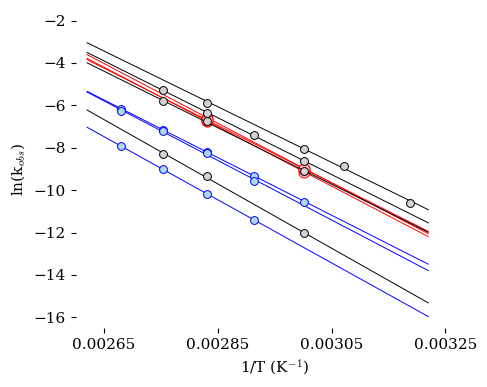

In [147]:
# pairs of substituent and concentration that had more than one temperature entry

#substituent_list = list(concs.keys())  # All the substituents that have multiple concentrations with multiple temperatures
substituent_list = ['H', 'p-Br', 'p-CH3', 'p-Cl', 'p-F', 'p-I', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 and Table 2
#substituent_list = ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 only

plt.style.use(github_location_styles + style_file)        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


for substituent in substituent_list:
    scs = list(set(concs[substituent]))
    for c in scs:
        print(substituent, c)
        df_temp = df.loc[(df['Substituent'] == substituent) & (df['%H2SO4'] == c), : ]
        print(df_temp)


        x = 1 / (df_temp['TempC'] + 273.15)   # x is 1/T
        y = np.log(df_temp['kobs']*1E-4)          # y is ln(k_obs)
        #ax.plot(x, y, 'o', color='black')

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.scatter(x,y, s = 64, color="pink",  edgecolors = "red", zorder=2, linewidths=0.7)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.scatter(x,y, s = 32, color="lightgray",  edgecolors = "black", zorder=4, linewidths=0.7)
        else:
            ax.scatter(x,y, s = 32, color="lightblue",  edgecolors = "blue", zorder=2, linewidths=0.7)

        # linear regression
        results = stats.linregress(x, y)
        slope = results.slope
        intercept = results.intercept
        r_value = results.rvalue
        p_value = results.pvalue
        std_err = results.stderr
        intercept_stderr = results.intercept_stderr

        slope_unc = unc.ufloat(slope, std_err)
        intercept_unc = unc.ufloat(intercept, intercept_stderr)

        print(f'slope: {slope_unc}, intercept: {intercept_unc}, r_value: {r_value}, std_err: {std_err}')

        # plot linear regression line
        x_fit = np.linspace(0.00262, 0.00322, 100)
#        x_fit = np.linspace(0, 0.00322, 100)
        y_fit = slope * x_fit + intercept

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.plot(x_fit, y_fit, '-', color='red', linewidth=0.7, zorder = 0)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.plot(x_fit, y_fit, '-', color='black', linewidth=0.7, zorder = 3)
        else:
            ax.plot(x_fit, y_fit, '-', color='blue', linewidth=0.7, zorder = 0)
        print()

        # calculate dH and dS from slope and intercept in erying plot
        R = 8.314  # J/mol-K
        kB = 1.380649e-23  # J/K
        NA = 6.02214076e23  # 1/mol
        h = 6.62607015e-34  # J-s

        Ea = -slope * R / 1000 /4.18 # kJ/mol
        A = (intercept)/2.303 # pre-exponential factor  

        Ea_unc = -slope_unc * R / 1000 /4.18 # kJ/mol
        A_unc = (intercept_unc)/2.303 # pre-exponential factor

        print(f'For substituent {substituent} at %H2SO4 = {c}: Ea = {Ea_unc:.2f} kcal/mol, A = {A_unc:.2f}')
        print('----------------------------------------')

ax.set_xlabel('1/T (K$^{-1}$)')
ax.set_ylabel('ln(k$_{obs}$)')
ax.set_xlim(0.0026, 0.0033)
#ax.set_xlim(0, 0.0033)
ax.set_ylim(-16.5,-1.5)
ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

plt.savefig('plots/21-Beckman-Fig-Y-Eyring.pdf')
plt.show()

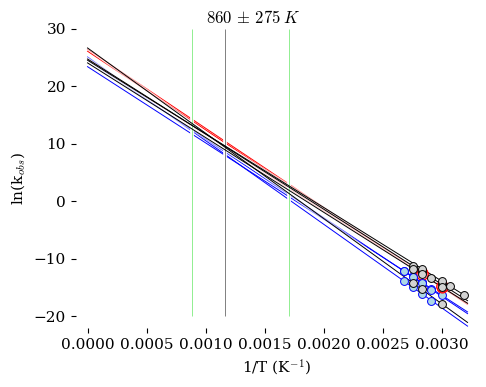

In [181]:
# pairs of substituent and concentration that had more than one temperature entry

#substituent_list = list(concs.keys())  # All the substituents that have multiple concentrations with multiple temperatures
substituent_list = ['H', 'p-Br', 'p-CH3', 'p-Cl', 'p-F', 'p-I', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 and Table 2
#substituent_list = ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 only

plt.style.use(github_location_styles + style_file)        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


for substituent in substituent_list:
    scs = list(set(concs[substituent]))
    for c in scs:
#        print(substituent, c)
        df_temp = df.loc[(df['Substituent'] == substituent) & (df['%H2SO4'] == c), : ]
#        print(df_temp)


        x = 1 / (df_temp['TempC'] + 273.15)   # x is 1/T
        y = np.log(df_temp['kobs']*1E-4/(df_temp['TempC'] + 273.15))          # y is ln(k_obs)
        #ax.plot(x, y, 'o', color='black')

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.scatter(x,y, s = 64, color="pink",  edgecolors = "red", zorder=3, linewidths=0.7)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.scatter(x,y, s = 32, color="lightgray",  edgecolors = "black", zorder=5, linewidths=0.7)
        else:
            ax.scatter(x,y, s = 32, color="lightblue",  edgecolors = "blue", zorder=3, linewidths=0.7)

        # linear regression
        results = stats.linregress(x, y)
        slope = results.slope
        intercept = results.intercept
        r_value = results.rvalue
        p_value = results.pvalue
        std_err = results.stderr
        intercept_stderr = results.intercept_stderr

        slope_unc = unc.ufloat(slope, std_err)
        intercept_unc = unc.ufloat(intercept, intercept_stderr)

#        print(f'slope: {slope_unc}, intercept: {intercept_unc}, r_value: {r_value}, std_err: {std_err}')

        # plot linear regression line
#        x_fit = np.linspace(0.00262, 0.00322, 100)
        x_fit = np.linspace(0, 0.00322, 100)
        y_fit = slope * x_fit + intercept

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            a=1
            ax.plot(x_fit, y_fit, '-', color='red', linewidth=0.7, zorder = 0)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.plot(x_fit, y_fit, '-', color='white', linewidth=2.7, alpha = 0.6, zorder = 1)
            ax.plot(x_fit, y_fit, '-', color='black', linewidth=0.7, zorder = 2)
        else:
            a=1
            ax.plot(x_fit, y_fit, '-', color='blue', linewidth=0.7, zorder = 0)
        print()

        # calculate dH and dS from slope and intercept in erying plot
        R = 8.314  # J/mol-K
        kB = 1.380649e-23  # J/K
        NA = 6.02214076e23  # 1/mol
        h = 6.62607015e-34  # J-s

        Ea = -slope * R / 1000 /4.18 # kJ/mol
        A = (intercept)/2.303 # pre-exponential factor  

        Ea_unc = -slope_unc * R / 1000 /4.18 # kJ/mol
        A_unc = (intercept_unc)/2.303 # pre-exponential factor

#        print(f'For substituent {substituent} at %H2SO4 = {c}: Ea = {Ea_unc:.2f} kcal/mol, A = {A_unc:.2f}')
#        print('----------------------------------------')

ax.set_xlabel('1/T (K$^{-1}$)')
ax.set_ylabel('ln(k$_{obs}$)')
#ax.set_xlim(0.0026, 0.0033)
ax.set_xlim(-0.0001, 0.0033)
#ax.set_ylim(-16.5,-1.5)
ax.set_ylim(-22,30)
#ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

ax.vlines(1/860, -20, 30, colors='white', linestyles='solid', linewidth=2.7, zorder=1)    
ax.vlines(1/(860+275), -20, 30, colors='white', linestyles='solid', linewidth=2.7, zorder=1)    
ax.vlines(1/(860-275), -20, 30, colors='white', linestyles='solid', linewidth=2.7, zorder=1)    
ax.vlines(1/860, -20, 30, colors='gray', linestyles='solid', linewidth=0.7, zorder=1)    
ax.vlines(1/(860+275), -20, 30, colors='lightgreen', linestyles='solid', linewidth=0.7, zorder=1)    
ax.vlines(1/(860-275), -20, 30, colors='lightgreen', linestyles='solid', linewidth=0.7, zorder=1) 

ax.text(0.0010, 31, r'$860\,\pm\,275\; K$', color='black', fontsize=12)
plt.savefig('plots/21-Beckman-Fig-Y-Eyring_zero.pdf')
plt.show()

# Eyring Plots

Below is the code for Erying plots. Stolen from the code above and altered.

H 98.2
       Name Substituent  %H2SO4  TempC  kobs
0  Hydrogen           H    98.2   60.0   1.8
1  Hydrogen           H    98.2   70.0   6.0
2  Hydrogen           H    98.2   80.0  17.0
3  Hydrogen           H    98.2   90.0  51.0
slope: (-1.305+/-0.019)e+04, intercept: 24.7+/-0.5, r_value: -0.9997939932349464, std_err: 187.33991500993216

For substituent H at %H2SO4 = 98.2: dS = 8.21+/-4.48 J/mol-K, dH = 108.50+/-1.56 J/mol
----------------------------------------
H 91.7
        Name Substituent  %H2SO4  TempC   kobs
6   Hydrogen           H    91.7   60.0   0.26
7   Hydrogen           H    91.7   70.0   0.90
8   Hydrogen           H    91.7   80.0   2.80
9   Hydrogen           H    91.7   90.0   7.80
10  Hydrogen           H    91.7  100.0  20.80
slope: (-1.324+/-0.013)e+04, intercept: 23.4+/-0.4, r_value: -0.9998531631906846, std_err: 131.0196994269532

For substituent H at %H2SO4 = 91.7: dS = -2.90+/-3.09 J/mol-K, dH = 110.08+/-1.09 J/mol
----------------------------------------
H

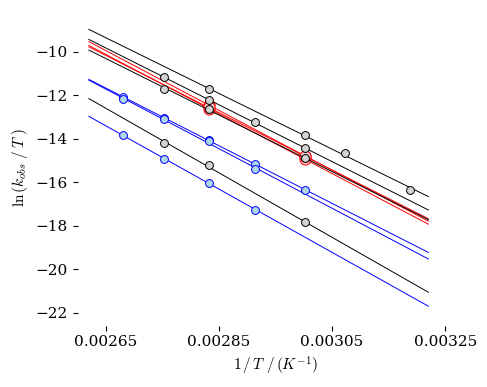

In [44]:
# pairs of substituent and concentration that had more than one temperature entry

#substituent_list = list(concs.keys())  # All the substituents that have multiple concentrations with multiple temperatures
substituent_list = ['H', 'p-Br', 'p-CH3', 'p-Cl', 'p-F', 'p-I', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 and Table 2
#substituent_list = ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 only

plt.style.use(github_location_styles + style_file)        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


for substituent in substituent_list:
    scs = list(set(concs[substituent]))
    for c in scs:
        print(substituent, c)
        df_temp = df.loc[(df['Substituent'] == substituent) & (df['%H2SO4'] == c), : ]
        print(df_temp)


        x = 1 / (df_temp['TempC'] + 273.15)   # x is 1/T
        y = np.log(df_temp['kobs']*1E-4/(df_temp['TempC'] + 273.15))          # y is ln(k_obs)
        #ax.plot(x, y, 'o', color='black')

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.scatter(x,y, s = 64, color="pink",  edgecolors = "red", zorder=2, linewidths=0.7)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.scatter(x,y, s = 32, color="lightgray",  edgecolors = "black", zorder=4, linewidths=0.7)
        else:
            ax.scatter(x,y, s = 32, color="lightblue",  edgecolors = "blue", zorder=2, linewidths=0.7)

        # linear regression
        results = stats.linregress(x, y)
        slope = results.slope
        intercept = results.intercept
        r_value = results.rvalue
        p_value = results.pvalue
        std_err = results.stderr
        intercept_stderr = results.intercept_stderr

        slope_unc = unc.ufloat(slope, std_err)
        intercept_unc = unc.ufloat(intercept, intercept_stderr)

        print(f'slope: {slope_unc}, intercept: {intercept_unc}, r_value: {r_value}, std_err: {std_err}')

        # plot linear regression line
        x_fit = np.linspace(0.00262, 0.00322, 100)
#        x_fit = np.linspace(0, 0.00322, 100)
        y_fit = slope * x_fit + intercept

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.plot(x_fit, y_fit, '-', color='red', linewidth=0.7, zorder = 0)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.plot(x_fit, y_fit, '-', color='black', linewidth=0.7, zorder = 3)
        else:
            ax.plot(x_fit, y_fit, '-', color='blue', linewidth=0.7, zorder = 0)
        print()

        # calculate dH and dS from slope and intercept in erying plot
        T = 60 + 273.15  # K
        R = 8.314  # J/mol-K 
        kB = 1.380649e-23  # J/K
        NA = 6.02214076e23  # 1/mol
        h = 6.62607015e-34  # J-s
        kappa = 1  # transmission coefficient

        dS = (intercept_unc - np.log(kappa*kB/h)) * R
        dH = -slope_unc * R  /1000


        print(f'For substituent {substituent} at %H2SO4 = {c}: dS = {dS:.2f} J/mol-K, dH = {dH:.2f} J/mol')
        print('----------------------------------------')

ax.set_xlabel(r'$1\,/\,T\ /\,(K^{-1})$')
ax.set_ylabel(r'$\ln{(k_{obs}\;/\;T\;})$')
ax.set_xlim(0.0026, 0.0033)
#ax.set_xlim(0, 0.0033)
#ax.set_ylim(-16.5,-1.5)
ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

plt.savefig('plots/21-Beckman-Fig-Y-Eyring2.pdf')
plt.show()

# Isokinetic Temperature

I will take the data above and plot dH vs dS

In [45]:
subs = ['p-OCH3', 'H', 'H', 'H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-F', 'p-Br', 'p-I']

acidconc = [85.8,    # %H2SO4
            79.3, 
            91.7, 
            98.2, 
            98.2, 
            98.2, 
            98.2, 
            98.2, 
            98.2, 
            98.2 ]

dH = [113.77,    # kJ/mole
      120.79,
      110.08,
      108.50,
      106.36,
      107.90,
      123.20,
      114.21,
      113.68,
      109.37]

dH_err = [4.16,    # kJ/mole
          0.36,
          1.09,
          1.56,
          3.77,
          3.62,
          6.02,
          0,
          0,
          0]

dS = [ 6.47,    # J/mole-K
      11.05,
      -2.90,
       8.21,
       6.43,
       2.57,
      24.14,
      22.34,
      19.45,
       7.66]

dS_err = [11.62,    # J/mole-K
           1.01, 
           3.09, 
           4.48, 
          11.40,
          10.36,
          17.26,
           0,
           0,
           0]

df_thermo = pd.DataFrame({
    'Substituent': subs,
    '%H2SO4': acidconc,
    'dH_kJmol': dH,
    'dH_err_kJmol': dH_err,
    'dS_JmolK': dS,
    'dS_err_JmolK': dS_err
})

df_thermo

,Substituent,%H2SO4,dH_kJmol,dH_err_kJmol,dS_JmolK,dS_err_JmolK
0,p-OCH3,85.8,113.77,4.16,6.47,11.62
1,H,79.3,120.79,0.36,11.05,1.01
2,H,91.7,110.08,1.09,-2.90,3.09
3,H,98.2,108.50,1.56,8.21,4.48
4,p-CH3,98.2,106.36,3.77,6.43,11.40
5,p-Cl,98.2,107.90,3.62,2.57,10.36
6,p-NO2,98.2,123.20,6.02,24.14,17.26
7,p-F,98.2,114.21,0.00,22.34,0.00
8,p-Br,98.2,113.68,0.00,19.45,0.00
9,p-I,98.2,109.37,0.00,7.66,0.00


In [57]:
df = df_thermo.copy()
print(df)
print(df['Substituent'].unique())
#substituent_list = list(concs.keys())  # All the substituents that have multiple concentrations with multiple temperatures
substituent_list = ['H', 'p-Br', 'p-CH3', 'p-Cl', 'p-F', 'p-I', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 and Table 2
substituent_list_line = ['H', 'p-CH3', 'p-Cl', 'p-NO2']  # The substituents used in the paper Table 1 only


  Substituent  %H2SO4  dH_kJmol  dH_err_kJmol  dS_JmolK  dS_err_JmolK
0      p-OCH3    85.8    113.77          4.16      6.47         11.62
1           H    79.3    120.79          0.36     11.05          1.01
2           H    91.7    110.08          1.09     -2.90          3.09
3           H    98.2    108.50          1.56      8.21          4.48
4       p-CH3    98.2    106.36          3.77      6.43         11.40
5        p-Cl    98.2    107.90          3.62      2.57         10.36
6       p-NO2    98.2    123.20          6.02     24.14         17.26
7         p-F    98.2    114.21          0.00     22.34          0.00
8        p-Br    98.2    113.68          0.00     19.45          0.00
9         p-I    98.2    109.37          0.00      7.66          0.00
['p-OCH3' 'H' 'p-CH3' 'p-Cl' 'p-NO2' 'p-F' 'p-Br' 'p-I']


In [58]:


# get list of unique values in Substituent column
substituents = df['Substituent'].unique()
substituents.sort()
substituents_list = substituents.tolist()
substituents_list


['H', 'p-Br', 'p-CH3', 'p-Cl', 'p-F', 'p-I', 'p-NO2', 'p-OCH3']

In [67]:


## Create a dictionary. Substituent as key, list of concentrations as values. 
## Only include concentrations that appear more than once.
## Then remove any items with empty lists.

# for each substituent get list of unique values in %H2SO4 column and put in a dictionary
concs = {}
for substituent in substituents_list:
    #print(substituent)
    sss = df.loc[df['Substituent'] == substituent, '%H2SO4']
    # remove all values in sss that appear only once
    #sss = sss[sss.duplicated(keep=False)]
    #print(sss)

    concs[substituent] = sss.tolist()

# remove empty dictionary items
concs = {k: v for k, v in concs.items() if v}
print(concs)


{'H': [79.3, 91.7, 98.2], 'p-Br': [98.2], 'p-CH3': [98.2], 'p-Cl': [98.2], 'p-F': [98.2], 'p-I': [98.2], 'p-NO2': [98.2], 'p-OCH3': [85.8]}


[ 8.21  6.43  2.57 24.14] [108500. 106360. 107900. 123200.] [ 4.48 11.4  10.36 17.26] [1560. 3770. 3620. 6020.]

ODR Linear Fit Results:
Slope (m): 859.3582
Intercept (c): 101987.5150

Optional: Display the full results summary
Beta: [   859.35821191 101987.51502139]
Beta Std Error: [ 274.66861072 2439.0111886 ]
Beta Covariance: [[  845164.55077211 -6781317.11130318]
 [-6781317.11130318 66642425.6872758 ]]
Residual Variance: 0.0892640914066441
Inverse Condition #: 0.0047986660180916645
Reason(s) for Halting:
  Sum of squares convergence

LEAST SQUARES scipy.optimize.curve_fit
slope: 797.8162651611483, intercept: 103242.57435889663
slope stdev: 155.0066769831035, intercept stdev: 2047.7512376073867
(103242.57435889663+/-2047.7512376073862, 797.8162651611483+/-155.0066769831035)
[103242.5743589     797.81626516]
[[4193285.13112258 -248379.83095876]
 [-248379.83095876   24027.06990934]]


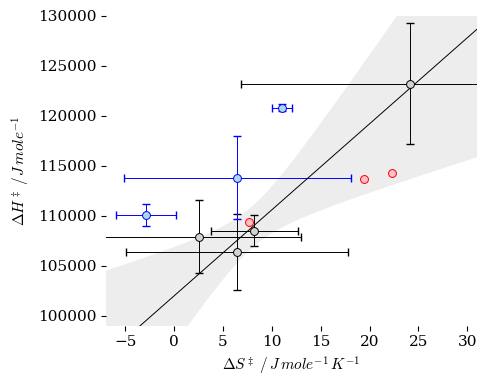

In [140]:


plt.style.use(github_location_styles + style_file)        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

x_line = []
y_line = []
x_line_err = []
y_line_err = []

for substituent in substituent_list:
    scs = list(set(concs[substituent]))
    for c in scs:
        #print(substituent, c)
        df_temp = df.loc[(df['Substituent'] == substituent) & (df['%H2SO4'] == c), : ]
        #print(df_temp)


        x = df_temp['dS_JmolK']   # x is entropy in Joules
        y = df_temp['dH_kJmol'] * 1000  # y is enthalpy in Joules          # y is ln(k_obs)
        x_err = df_temp['dS_err_JmolK']   # x is entropy in Joules
        y_err = df_temp['dH_err_kJmol'] * 1000  # y is enthalpy in Joules          # y is ln(k_obs)
        #ax.plot(x, y, 'o', color='black')

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.scatter(x,y, s = 32, color="pink",  edgecolors = "red", zorder=2, linewidths=0.7)
            ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none', ecolor='red', color='red', elinewidth=0.7, capsize=3, zorder=1)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2']:
            ax.scatter(x,y, s = 32, color="lightgray",  edgecolors = "black", zorder=4, linewidths=0.7)
            ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none', ecolor='black', color='black', elinewidth=0.7, capsize=3, zorder=1, marker = None)
            y_line.append(y)
            x_line.append(x)
            y_line_err.append(y_err)
            x_line_err.append(x_err)
        else:
            ax.scatter(x,y, s = 32, color="lightblue",  edgecolors = "blue", zorder=2, linewidths=0.7)
            ax.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='none', ecolor='blue', color='blue', elinewidth=0.7, capsize=3, zorder=1)




x_line = np.array(x_line).flatten()
y_line = np.array(y_line).flatten()
x_line_err = np.array(x_line_err).flatten()
y_line_err = np.array(y_line_err).flatten()

print(x_line, y_line, x_line_err, y_line_err)


#ax.scatter(x_line, y_line, s = 64, color="green",  edgecolors = "blue", zorder=2, linewidths=0.7)
#ax.errorbar(x_line, y_line, xerr=x_line_err, yerr=y_line_err, fmt='none', ecolor='black', color='black', elinewidth=0.7, capsize=3, zorder=1)

import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import *
import scipy

# 1. Define the linear function to fit
def linear_func(p, x):
    """Linear function y = mx + c"""
    m, c = p
    return m * x + c

# 2. Generate some example data with errors
x = x_line
y = y_line
# Define your horizontal (x) and vertical (y) errors
x_err = x_line_err
y_err = y_line_err

# 3. Create a Model, RealData, and ODR object
# 'f' is the function, 'ifixb' specifies which parameters are fixed (if any)
linear_model = Model(linear_func)
# RealData takes x data, y data, and their respective errors (sx for x, sy for y)
data = RealData(x, y, sx=x_err, sy=y_err)

# Set up ODR with the data and model, providing initial parameter estimates (beta0)
odr_instance = ODR(data, linear_model, beta0=[1., 0.]) # Initial guess for m and c

# 4. Run the regression
output = odr_instance.run()

# 5. Get the results and print them
# output.beta contains the optimized parameters (m, c)
slope_odr, intercept_odr = output.beta
print(f"\nODR Linear Fit Results:")
print(f"Slope (m): {slope_odr:.4f}")
print(f"Intercept (c): {intercept_odr:.4f}")

print("\nOptional: Display the full results summary")
output.pprint()

# plot linear regression line
x_fit = np.linspace(x_line.min(), x_line.max(), 100)
x_fit = np.linspace(-10, 50, 100)
#x_fit = np.linspace(0, 0.00322, 100)
y_fit = slope_odr * x_fit + intercept_odr
ax.plot(x_fit, y_fit, '-', color='black', linewidth=0.7, zorder = 3)



ax.set_xlabel(r'$\Delta S^\ddagger \;/\, J\,mole^{-1}\,K^{-1}$')
ax.set_ylabel(r'$\Delta H^\ddagger \;/\, J\,mole^{-1}$')
#ax.set_xlim(0.0026, 0.0033)
ax.set_xlim(-7, 31)
ax.set_ylim(99000, 125000)
#ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
ax.set_yticks([100000, 105000, 110000, 115000, 120000, 125000, 130000])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 

def linear_func(slope, int, x):
    """Linear function y = mx + c"""
    return slope * x + int

popt,pcov = scipy.optimize.curve_fit(linear_func, x_line, y_line, 
 #                                    sigma=y_line_err
                                     )
stderr = pcov.diagonal()**0.5

print('\nLEAST SQUARES scipy.optimize.curve_fit')
print(f'slope: {popt[1]}, intercept: {popt[0]}')
print(f'slope stdev: {stderr[1]}, intercept stdev: {stderr[0]}')
popt_un = unc.correlated_values(popt, pcov)
print(popt_un)
print(popt)
print(pcov)

def linear_func(p, x):
    """Linear function y = mx + c"""
    m, c = p
    return m * x + c

popt_un = unc.correlated_values(output.beta, output.cov_beta * output.res_var)

################################################################################
### Create Confidence band upper and lower bounds
################################################################################

sigma = 2

bestfit_y_fit = linear_func(popt_un, x_fit)
dev = unp.std_devs(bestfit_y_fit) * sigma

fit_up = unp.nominal_values(bestfit_y_fit) + dev
fit_dn = unp.nominal_values(bestfit_y_fit) - dev
ax.fill_between(x_fit, fit_up, fit_dn, 
                   color="lightgray", alpha=0.4, zorder = 0,
                   linewidth=0, label="confidence interval")


plt.savefig('plots/21-Beckman-Fig-Y-Eyring-Isokinetic.pdf')
plt.show()

In [135]:
def linear_func(p, x):
    """Linear function y = mx + c"""
    m, c = p
    return m * x + c

popt_un = unc.correlated_values(output.beta, output.cov_beta * output.res_var)

################################################################################
### Create Confidence band upper and lower bounds
################################################################################

sigma = 2

bestfit_y_fit = linear_func(popt_un, x_fit)
dev = unp.std_devs(bestfit_y_fit) * sigma

fit_up = unp.nominal_values(bestfit_y_fit) + dev
fit_dn = unp.nominal_values(bestfit_y_fit) - dev
ax.fill_between(x_fit, fit_up, fit_dn, 
                   color="lightgray", alpha=0.4, zorder = 0,
                   linewidth=0, label="confidence interval")


In [130]:
dir(output)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'beta',
 'cov_beta',
 'delta',
 'eps',
 'info',
 'inv_condnum',
 'iwork',
 'pprint',
 'rel_error',
 'res_var',
 'sd_beta',
 'stopreason',
 'sum_square',
 'sum_square_delta',
 'sum_square_eps',
 'work',
 'work_ind',
 'xplus',
 'y']

In [ ]:
        # linear regression
        results = stats.linregress(x, y)
        slope = results.slope
        intercept = results.intercept
        r_value = results.rvalue
        p_value = results.pvalue
        std_err = results.stderr
        intercept_stderr = results.intercept_stderr

        slope_unc = unc.ufloat(slope, std_err)
        intercept_unc = unc.ufloat(intercept, intercept_stderr)

        print(f'slope: {slope_unc}, intercept: {intercept_unc}, r_value: {r_value}, std_err: {std_err}')

        # plot linear regression line
        x_fit = np.linspace(0.00262, 0.00322, 100)
#        x_fit = np.linspace(0, 0.00322, 100)
        y_fit = slope * x_fit + intercept

        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.plot(x_fit, y_fit, '-', color='red', linewidth=0.7, zorder = 0)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.plot(x_fit, y_fit, '-', color='black', linewidth=0.7, zorder = 3)
        else:
            ax.plot(x_fit, y_fit, '-', color='blue', linewidth=0.7, zorder = 0)
        print()

        # calculate dH and dS from slope and intercept in erying plot
        T = 60 + 273.15  # K
        R = 8.314  # J/mol-K 
        kB = 1.380649e-23  # J/K
        NA = 6.02214076e23  # 1/mol
        h = 6.62607015e-34  # J-s
        kappa = 1  # transmission coefficient

        dS = (intercept_unc - np.log(kappa*kB/h)) * R
        dH = -slope_unc * R  /1000


        print(f'For substituent {substituent} at %H2SO4 = {c}: dS = {dS:.2f} J/mol-K, dH = {dH:.2f} J/mol')
        print('----------------------------------------')


[98.2, 98.2, 98.2, 98.2, 91.7, 91.7, 91.7, 91.7, 91.7, 79.3, 79.3, 79.3, 79.3]

In [ ]:
sss = df.loc[df['Substituent'] == 'p-OCH3', '%H2SO4']

# remove all values in sss that appear only once
sss = sss[sss.duplicated(keep=False)]
sss

34    98.2
36    85.8
37    85.8
38    85.8
39    85.8
68    98.2
Name: %H2SO4, dtype: float64

In [ ]:




# Now create a dictionary of dataframes for each substituent
dfs = {}
for substituent in substituents_list:
    dfs[substituent] = df.loc[df['Substituent'] == substituent]
# remove all entries in dataframe that contain only one record
    if len(dfs[substituent]) < 2:
        del dfs[substituent]
#check
dfs.keys()





In [ ]:

# for each entry in the dictionary separate the entry according to %H2SO4 column
dfs_by_conc = {}
for substituent in substituents_list:
    dfs_by_conc[substituent] = {}
    for conc in concs[substituent]:
        dfs_by_conc[substituent][conc] = dfs[substituent].loc[dfs[substituent]['%H2SO4'] == conc]
# checking


for substituent in substituents_list:
     print(substituent)
     print(dfs[substituent])

dfs_by_conc

KeyError: 'm-Br'

In [ ]:
# Plot Eyring plots for each substituent
plt.figure(figsize=(8,6))
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h']
for i, substituent in enumerate(substituents_list):
    df_sub = dfs[substituent]
    T = df_sub['TempC']+273.15
    k = df_sub['kobs']
    ln_k_T = np.log(k / T)
    inv_T = 1 / T
    plt.scatter(inv_T, ln_k_T, label=substituent, marker=markers[i % len(markers)])
    # Fit line
    slope, intercept, r_value, p_value, std_err = stats.linregress(inv_T, ln_k_T)
    x_fit = np.linspace(min(inv_T), max(inv_T), 100)
    y_fit = slope * x_fit + intercept
    plt.plot(x_fit, y_fit, linestyle='--')  
plt.xlabel('1/T (K$^{-1}$)')
plt.ylabel('ln(k/T) (K$^{-1}$)')
plt.title('Eyring Plots for Different Substituents')
plt.legend()
plt.grid()
plt.show()  

